In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
a = 0.1
b = 0.9
u_star = a + b
v_star = b / ((a+b)**2)
gamma = 1000

In [3]:
L, N = 1, 200
dx = L / (N - 1)

In [4]:
u = np.full(N, u_star)
v = np.full(N, v_star)

In [5]:
rng = np.random.default_rng(2)

amp = 0.02
u = u + rng.uniform(-amp, amp, size=u.shape)
v = v + rng.uniform(-amp, amp, size=v.shape)

In [6]:
def schnakenberg_laplacian(x, dx, g_left, g_right):
    ''' 
    second derivative using Neumann ghost boundaries for the laplacian.
    derivation using 3-point central difference. Non-zero case is untested.
    '''
    x_pad = np.pad(x, pad_width=1, mode='edge')

    # x_ghost_left = x[0] - 2 * dx * g_left
    x_pad[0] = x[0] - 2 * dx * g_left
    # x_ghost_right = x[0] - 2 * dx * g_right
    x_pad[-1] = x[-1] + 2 * dx * g_right

    d2 = ((x_pad[2:] - (2 * x_pad[1:-1])+ x_pad[:-2])) /  (dx**2)
    return d2


In [ ]:
dt = 0.001
n_step = 1e5
k = 100
Dv = 10

In [8]:
def timestep(u, v, dx=dx, dt=((0.2* dx**2)/Dv), n_step=n_step, k=k, gamma=gamma, a=a, b=b, Dv=Dv):
    history_u = []
    history_v = []
    for step in range(int(n_step)):
        if step % k == 0:
            history_u.append(u.copy())
            history_v.append(v.copy())

        L_u = schnakenberg_laplacian(u, dx, g_left=0.0, g_right=0.0)
        L_v = schnakenberg_laplacian(v, dx, g_left=0.0, g_right=0.0)

        f_u = gamma * (a - u + ((u**2)*v))
        g_v = gamma * (b - ((u**2)*v))

        u = u + dt * (L_u + f_u)
        v = v + dt * ((Dv*L_v) + g_v)

    return np.asarray(history_u), np.asarray(history_v)


In [9]:
hist_u, hist_v = timestep(u,v)

In [10]:
x = np.linspace(0, L, N)

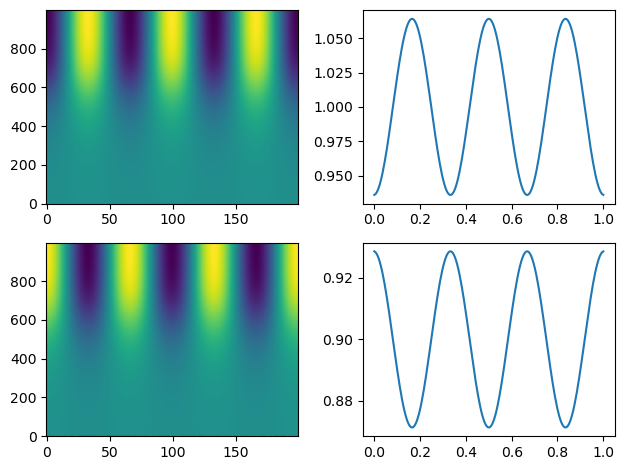

In [11]:
fig, ax = plt.subplots(2,2)
ax[0,0].imshow(hist_u, aspect='auto', origin='lower')
ax[1,0].imshow(hist_v, aspect='auto', origin='lower')
ax[0,1].plot(x, hist_u[-1])
ax[1,1].plot(x, hist_v[-1])
fig.tight_layout()

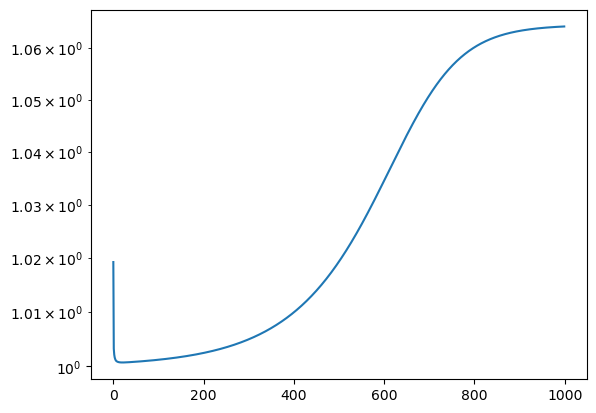

In [12]:
plt.plot(np.arange(0,1000,1), hist_u.max(axis=1))
plt.yscale('log')
plt.show()